In [483]:
# from google.colab import drive # remove the cell if not using colab
# drive.mount('/content/drive')

In [484]:
import pandas as pd
import numpy as np
import seaborn as sns
from pathlib import Path
base_path = Path(r"C:\Users\iraan\kursml\ml-wakacyjne-wyzwanie-2026\01_przetwarzanie_wizualizacja_danych") # change to path folder with data 


# Analiza i przetwarzanie danych na temat Titanica

#### Wyobraź sobie, że pewnego wakacyjnego dnia, będąc na plaży w pełnym słońcu, odbierasz telefon od nieznanego numeru.
Robisz to niechętnie — zasłużyłeś/aś przecież na odpoczynek i chcesz mieć ten czas tylko dla siebie. Już masz na końcu języka wymijającą odpowiedź, gdy nagle z drugiej strony słyszysz:
„Czy jesteś gotowy, by tego lata rozwikłać jedną z największych zagadek ludzkości?”

Jako osoba z natury ciekawa świata i ze świetnym umysłem analitycznym, szybko zapominasz o plaży i wakacjach. Zaintrygowany/a dopytujesz o szczegóły, ale rozmówca nie chce zdradzić zbyt wiele. Wiadomo jedynie, że chodzi o *zatonięcie Titanica w 1914* roku, a celem misji jest ustalenie, które osoby miały szansę przeżyć.

**Ty** — jako **renomowany analityk danych** — byłeś/byłaś ich pierwszym wyborem do analizy i oczyszczenia danych. Mimo wątpliwości postanawiasz podjąć się zadania, mając nadzieję, że twoja wiedza może zostać praktycznie wykorzystana w słusznym celu.

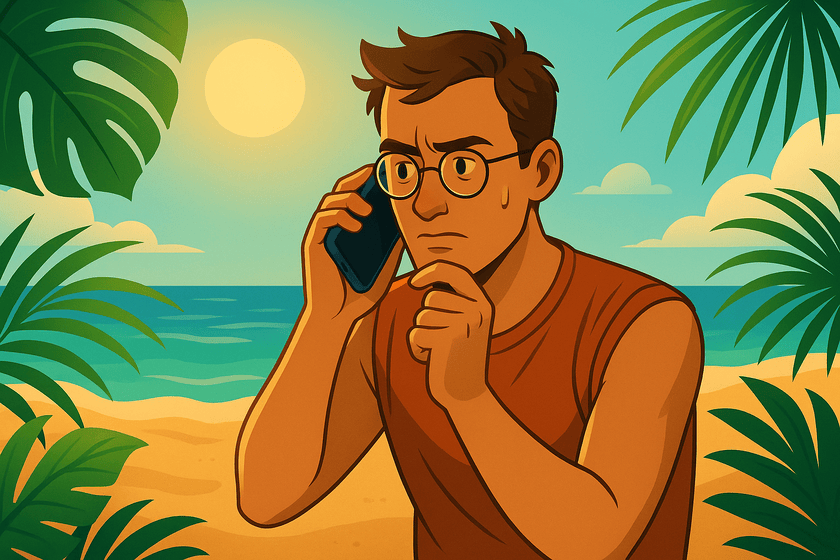

(*AI-generated image*)


#### Twoim celem będzie przeanalizowanie i przetworzenie zbioru danych w taki sposób, by mógł on być użyty do nauki modelu do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

(Uwaga: w tym zadaniu nie będziesz trenować modeli, ta przyjemność spotka cię w następnych notebookach)

Poniżej znajdziesz pytania, które mogą być pomocne w analizie, oraz odwołania do poszczególnych sekcji z notebooka do lekcji:

- Czy wszystkie kolumny są istotne w kontekście zadania?
- Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz? (sekcja #2.1)
- Czy typy danych są odpowiednie do znaczenia kolumny? (sekcja #1.3)
- Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne? (sekcja #4.1 + wykład)
- Która zmienna oznacza predykowaną klasę?
- Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych, jak i numerycznych? (sekcja #4.1)
- Czy końcowe rozkłady zawierają wartości skrajne? (sekcja #4.2 + wykład)

Wymagania:

- Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących wartości (sekcja #2.1)
- Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2)
- Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3)
- Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych
- Każda cecha powinna być zwizualizowana co najmniej raz. Sam(a) zastanów się, czy warto wizualizować cechy parami w celu odkrycia zależności między nimi (sekcja #4.4)
- Nie ma ograniczenia na liczbę komórek, ale zastanów się, czy dana wizualizacja/obliczenie jest przydatne w całej analizie, czy po prostu sobie "egzystuje" bez żadnych wniosków

Zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Poniżej zamieszczamy tabelę z wyjaśnieniem poszczególnych kolumn:

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |
                                                         |


In [485]:
titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')

In [486]:
titanic_df.Survived.value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [487]:
titanic_df['Cabin'].str[0].unique()

array([nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T'], dtype=object)

In [488]:
titanic_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [489]:
titanic_df.info()
titanic_df.nunique()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      793 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


Survived      2
Pclass        3
Name        891
Sex           2
Age          88
SibSp         7
Parch         7
Ticket      681
Fare        236
Cabin       147
Embarked      3
dtype: int64

Metoda do boxplotów dla kolumn numerycznych

In [490]:
def boxplot_numeric_outliers(df, column):
    plt.boxplot(df[column])
    plt.title(f'Wartości odstające - {column}')
    plt.xlabel(column)
    plt.ylabel('Wartość')
    plt.xticks(rotation=45)
    plt.show()

Metoda do wykresów słupkowych dla danych kategorialnych

In [491]:
def plot_categorical_column(df, column_name):
    counts = df[column_name].value_counts()

    plt.figure(figsize=(6, 4))
    counts.plot(kind='bar', color='steelblue', edgecolor='black')
    plt.title(f'Distribution of {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.show()

Tworzę nową kolumnę z rozmiarem rodziny i usuwam SibSp oraz Parch

In [492]:
titanic_df['FamilySize'] = titanic_df['SibSp'] + titanic_df['Parch'] + 1
titanic_df = titanic_df.drop(columns=['SibSp', 'Parch'])

Sprawdziłam ile jest braków i gdzie są

In [493]:
def get_percentage_missing(df, axis):
  missing_rows = df.isna().sum(axis=axis)
  missing_rows_perc = np.round(missing_rows / df.shape[axis] * 100, 2)
  return missing_rows_perc[missing_rows_perc > 0]

In [494]:
missing_cols_mi = get_percentage_missing(titanic_df, axis=0)
missing_cols_mi

Age         19.87
Fare        11.00
Cabin       77.10
Embarked     0.22
dtype: float64

Wyciągam literę pokładu do kolumny Deck, wartości brakujące zamieniam na 'Unknown'.

Stworzyłam nową kolumnę HasCabin, żeby nie usuwać wierszy z wartościami brakującymi dla kolumny Cabin, ponieważ braków jest 77%. Za dużo wierszy do usunięcia.

In [495]:
titanic_df['Deck'] = titanic_df['Cabin'].str[0]
titanic_df['Deck'] = titanic_df['Deck'].fillna('Unknown')  # 77% braków -> osobna kategoria
titanic_df['HasCabin'] = titanic_df['Cabin'].notna().astype(int)
titanic_df = titanic_df.drop(columns=['Cabin'])

Sprawdzam przeżywalność według pokładu.

In [496]:
titanic_df.groupby('Deck')['Survived'].mean()

Deck
A          0.466667
B          0.744681
C          0.593220
D          0.757576
E          0.750000
F          0.615385
G          0.500000
T          0.000000
Unknown    0.299854
Name: Survived, dtype: float64

Wykres słupkowy dla wartości Fare oraz Age, żeby sprawdzić jak wygląda rozkład.

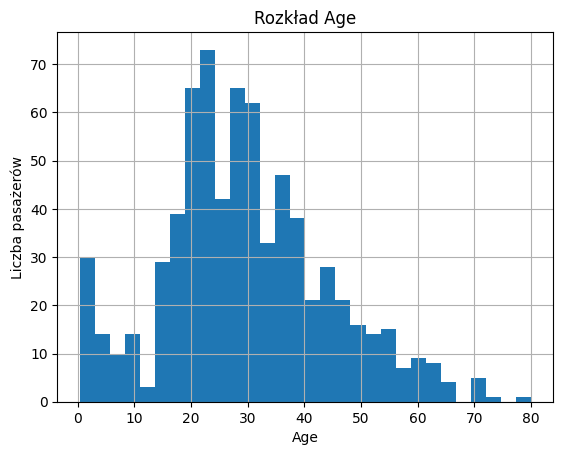

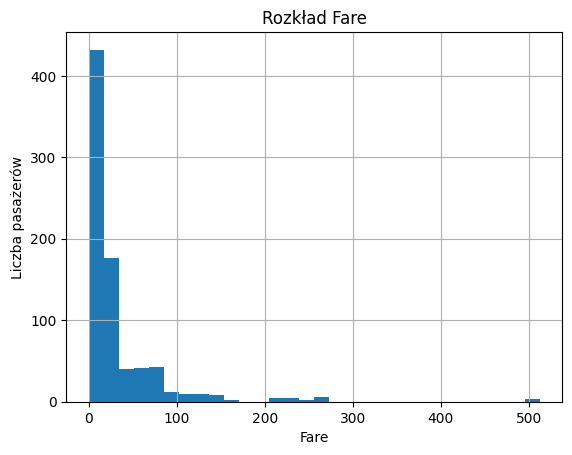

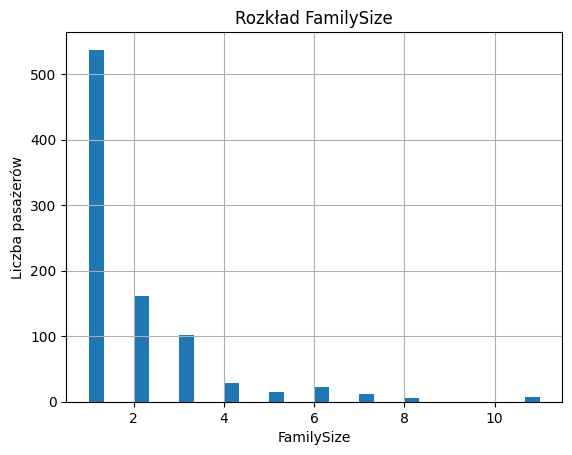

In [497]:
import matplotlib.pyplot as plt

numeric_cols = ['Age', 'Fare', 'FamilySize']

for col in numeric_cols:
    titanic_df[col].hist(bins=30)
    plt.title(f'Rozkład {col}')
    plt.xlabel(col)
    plt.ylabel('Liczba pasażerów')
    plt.show()


dwa rozkłady są asymetryczne - wypełniamy braki medianą

In [498]:
titanic_df['Age'] = titanic_df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
titanic_df['Age'].isna().sum()

np.int64(0)

In [499]:
titanic_df['Fare'] = titanic_df.groupby('Pclass')['Fare'].transform(lambda x: x.fillna(x.median()))
titanic_df['Fare'].isna().sum()

np.int64(0)

Boxploty dla Fare, Age oraz FamilySize

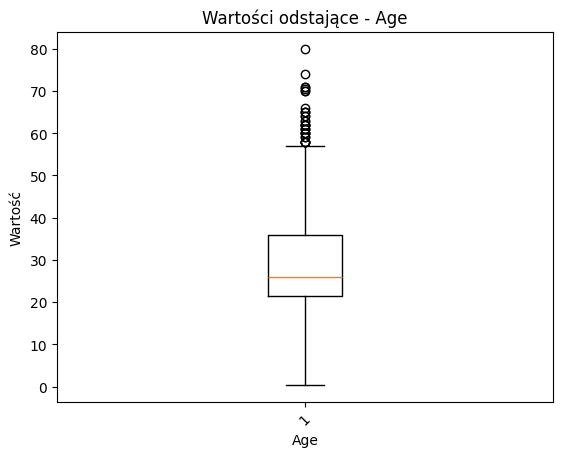

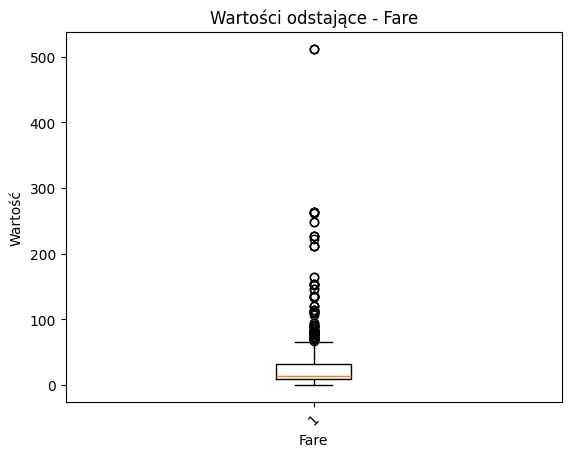

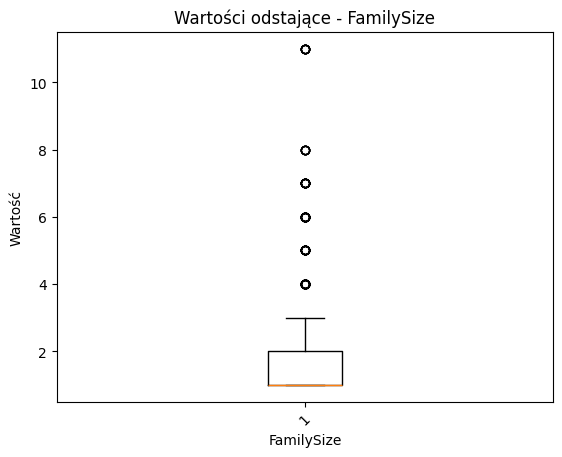

In [500]:
numeric_features = ['Age', 'Fare', 'FamilySize']
for feature in numeric_features:
    boxplot_numeric_outliers(titanic_df, feature)

Age: wartości odstające występują powyżej okołó 57 lat, oznacza to że niewiele było osób w wysokim wieku. Najstarsza osoba ma 80 lat, co jest możliwe, więc nie usuwam te wartości

Fare: wartości odstające zaczynają występować gdzieś od 80 i tych wartości jest dużo. Najwyższa Fare jest 500, co jest możliwe dla opłaty biletu. Też nie usuwam tych wartości

FamilySize: na tym wykresie jest niewiele wartości odstających, ktorę zaczynają się od 4, czyli osób podróżujących z większą rodziną jest mało. Najwięszka rodzina ma około 11 osób, co też jest możliwe w tym przypadku. Też nie usuwam 


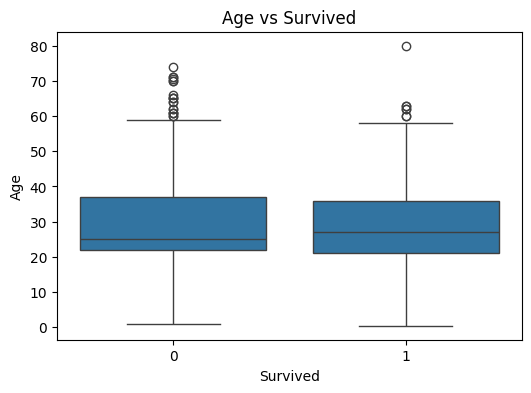

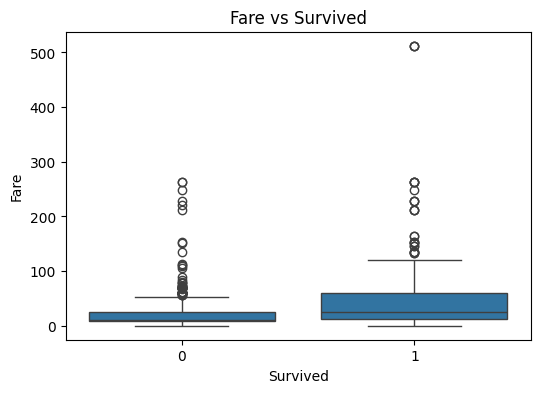

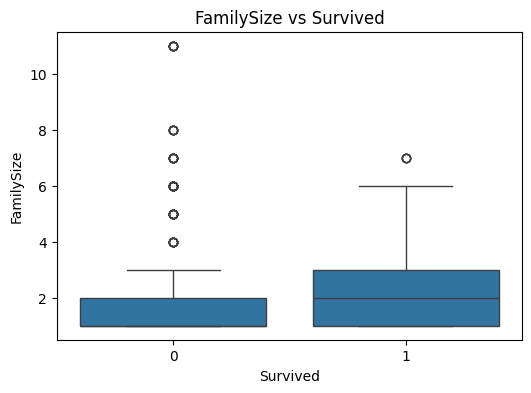

In [501]:
def boxplot_by_survived(df, column):
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x='Survived', y=column)
    plt.title(f'{column} vs Survived')
    plt.xlabel('Survived')
    plt.ylabel(column)
    plt.show()

for feature in ['Age', 'Fare', 'FamilySize']:
    boxplot_by_survived(titanic_df, feature)

Sprawdzam dokładne wartości median dla Fare, przy dużej skali trudne jest poprawnie oszacować wartości

In [502]:
titanic_df.groupby('Survived')['Fare'].median()

Survived
0     9.5875
1    26.0000
Name: Fare, dtype: float64

Sprawdzam średnią przeżywalność dla każdego FamilySize

In [503]:
titanic_df.groupby('FamilySize')['Survived'].mean()

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

# Age 
Age jest słabym predyktorem przeżycia, ponieważ obie grupy są mniej więcej w przedziale od 21 do 37 lat. Mediany obu przypadków są zbliżone do siebie (0 - 25 lat, 1 - 27 lat) 
# Fare
Mediana dla zmarłych jest ~10, a dla ocalałych - 26. W tym przypadku widać, że osoby które zapłaciły więcej miały większą przeżywalność. Czyli Fare ma silniejszy związek z przeżyciem.
# FamilySize
Mediana dla zmarłych jest 1, gdy dla ocalałych - 2. Czyli osoby, które podróżowały większą rodziną, miały większą szansę przeżycia. Ze średnich wwartości widać, że to nie jest liniowe. Wynika to z wartości średnich przeżywalności dla każdej wartości FamilySize. Przeżywalność rośnie do 72% dla rodzin 4-osobowych, po czym spada do 0-33% dla rodzin, które miały 5 osób i więcej.

Następnie dodałam kolumnę Title, która zawiera tytuły. Wybrałam główne tytuły (Mr, Miss, Mrs, Master), pozostałe zaznaczyłam jako Other.

In [504]:
titanic_df['Title'] = titanic_df['Name'].str.extract(r',\s*([^\.]+)\.')
titanic_df = titanic_df.drop(columns=['Name'])

main_titles = ['Mr', 'Miss', 'Mrs', 'Master']
is_main_title = titanic_df['Title'].isin(main_titles)
titanic_df.loc[~is_main_title, 'Title'] = 'Other'

titanic_df["Title"].value_counts(normalize=True) * 100

Title
Mr        58.024691
Miss      20.426487
Mrs       14.029181
Master     4.489338
Other      3.030303
Name: proportion, dtype: float64

Tu kategorie Master i Other występują rzadko. Jednak to nie są błędne wartości, więc nie usuwam je.

In [505]:
titanic_df = pd.get_dummies(data=titanic_df, columns=['Title'], prefix='Title', dtype = np.int32)
titanic_df.head(n=1)

,Survived,Pclass,Sex,Age,Ticket,Fare,Embarked,FamilySize,Deck,HasCabin,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Other
PassengerId,,,,,,,,,,,,,,,
1,0,3,male,22.0,A/5 21171,7.25,S,2,Unknown,0,0,0,1,0,0


Kolumna Embarked ma dane kategorialne, więc można uzupełnić braki modą

In [506]:
titanic_df['Embarked'] = titanic_df['Embarked'].fillna(titanic_df['Embarked'].mode()[0])
titanic_df["Embarked"].value_counts(normalize=True) * 100


Embarked
S    72.502806
C    18.855219
Q     8.641975
Name: proportion, dtype: float64

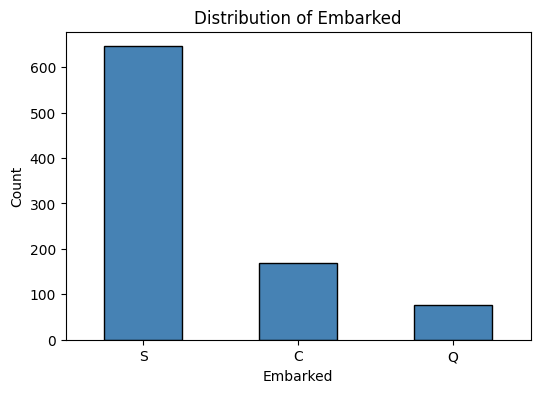

In [507]:
plot_categorical_column(titanic_df, 'Embarked')

W tym przypadku Q występuje rzadko

In [508]:
titanic_df.groupby(['Sex', 'Embarked'])['Survived'].mean()

Sex     Embarked
female  C           0.876712
        Q           0.750000
        S           0.692683
male    C           0.305263
        Q           0.073171
        S           0.174603
Name: Survived, dtype: float64

Najwyższą przeżywalność mają kobiety 88%. Dla mężczyzn i dla kobiet przeżywalność jest wyższa dla portu C. Przeżywalność zależała od portu oraz płci 

One-hot encoding dla kolmnu Embarked

In [509]:
titanic_df = pd.get_dummies(data=titanic_df, columns=['Embarked'], prefix='Embarked', dtype = np.int32)
titanic_df.head(n=1)

,Survived,Pclass,Sex,Age,Ticket,Fare,FamilySize,Deck,HasCabin,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Other,Embarked_C,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,,,,,,,,
1,0,3,male,22.0,A/5 21171,7.25,2,Unknown,0,0,0,1,0,0,0,0,1


One-hot encoding dla Deck

In [510]:
titanic_df = pd.get_dummies(data=titanic_df, columns=['Deck'], prefix='Deck', dtype=np.int32)
titanic_df.head(n=1)

,Survived,Pclass,Sex,Age,Ticket,Fare,FamilySize,HasCabin,Title_Master,Title_Miss,...,Embarked_S,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown
PassengerId,,,,,,,,,,,,,,,,,,,,,
1,0,3,male,22.0,A/5 21171,7.25,2,0,0,0,...,1,0,0,0,0,0,0,0,0,1


Kodowanie kolumny Sex, wykorzystując binary encoding

In [511]:
titanic_df['Sex'] = titanic_df['Sex'].map({
    'male': 0, 'female': 1
    })
titanic_df['Sex'].value_counts(normalize=True) * 100

Sex
0    64.758698
1    35.241302
Name: proportion, dtype: float64

Pclass zostawiłam jako zmienną numeryczną, ponieważ im mniejsza klasa, im mniejsza przeżywalność.

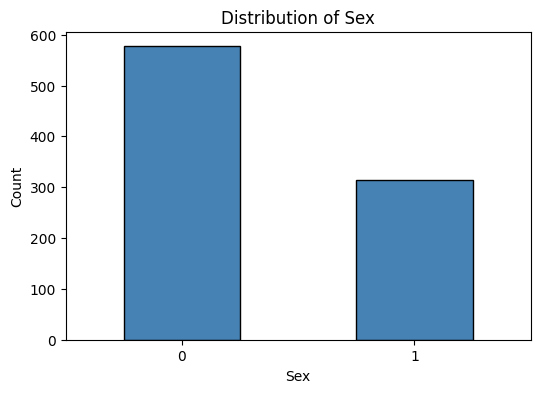

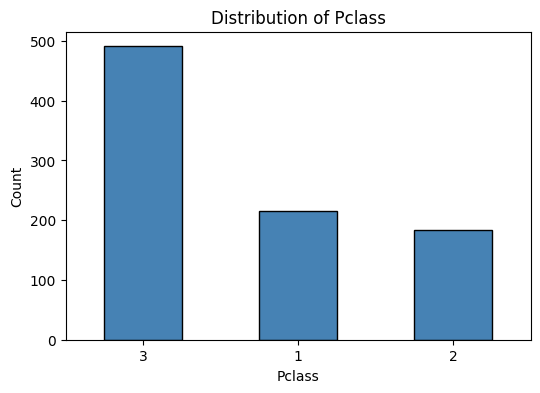

In [512]:
plot_categorical_column(titanic_df, 'Sex')
plot_categorical_column(titanic_df, 'Pclass')

Usuwam Ticket, ponieważ to unikalne wartości bez czytelnej struktury

In [513]:
titanic_df = titanic_df.drop(columns=['Ticket'])
titanic_df.head(n=1)

,Survived,Pclass,Sex,Age,Fare,FamilySize,HasCabin,Title_Master,Title_Miss,Title_Mr,...,Embarked_S,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown
PassengerId,,,,,,,,,,,,,,,,,,,,,
1,0,3,0,22.0,7.25,2,0,0,0,1,...,1,0,0,0,0,0,0,0,0,1


In [514]:
missing_cols_mi = get_percentage_missing(titanic_df, axis=0)
missing_cols_mi

Series([], dtype: float64)

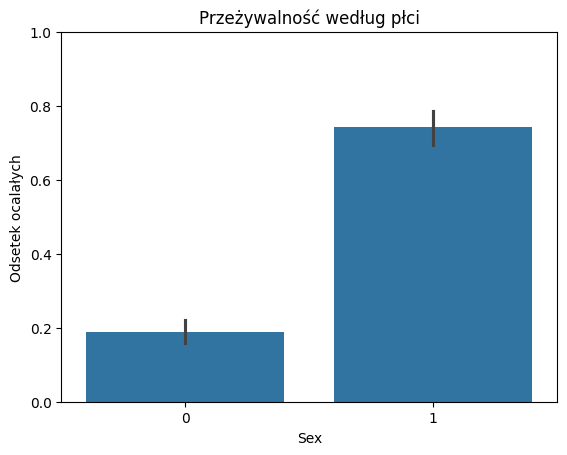

In [515]:
sns.barplot(data=titanic_df, x='Sex', y='Survived')

plt.title('Przeżywalność według płci')
plt.ylabel('Odsetek ocalałych')
plt.ylim(0, 1)
plt.show()

Z wykresów widać, że u kobiet przeżywalność jest wyższa. Dodatkowo z wykresów wyżej można zauważyć, że kobiet było mniej. Mimo to większy odsetek kobiet przeżył.

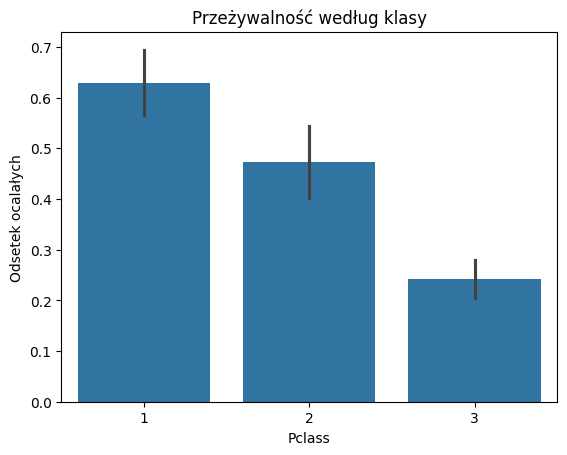

In [516]:
sns.barplot(data=titanic_df, x='Pclass', y='Survived')

plt.title('Przeżywalność według klasy')
plt.ylabel('Odsetek ocalałych')
plt.show()

Na tym wykresie widać, że im lepsza klasa, tym większa przeżywalność. Pasażerowie pierwszej klasy mieli największe szanse na przeżycie, podczas gdy pasażerowie pierwszej klasy mieli największe szanse, chociąż pasażerów trzeciej klasy było więcej.

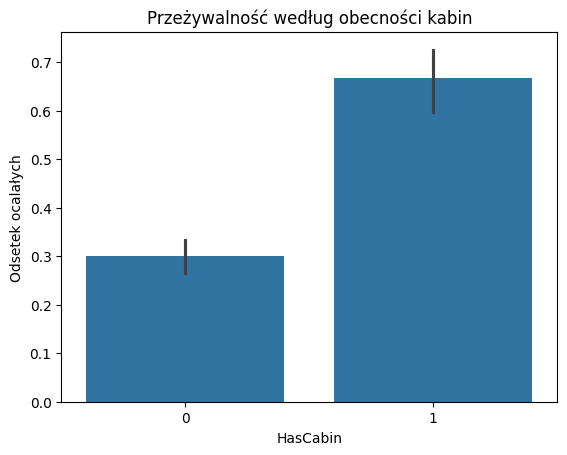

In [517]:
sns.barplot(data=titanic_df, x='HasCabin', y='Survived')

plt.title('Przeżywalność według obecności kabin')
plt.ylabel('Odsetek ocalałych')
plt.show()

Tutaj widać zależność pomiędzy zanotowanym numerem kabiny oraz przeżywalnością. Osoby, które miały numer kabiny miały większe szanse na przeżycie

In [518]:
titanic_df.groupby(['Sex','HasCabin'])['Survived'].mean()

Sex  HasCabin
0    0           0.136170
     1           0.420561
1    0           0.654378
     1           0.938144
Name: Survived, dtype: float64

In [519]:
titanic_df.groupby(['FamilySize','HasCabin'])['Survived'].mean()

FamilySize  HasCabin
1           0           0.243792
            1           0.585106
2           0           0.421053
            1           0.742424
3           0           0.520548
            1           0.724138
4           0           0.700000
            1           0.777778
5           0           0.076923
            1           1.000000
6           0           0.055556
            1           0.500000
7           0           0.333333
8           0           0.000000
11          0           0.000000
Name: Survived, dtype: float64

In [520]:
titanic_df.groupby(['Sex','Pclass'])['Survived'].mean()

Sex  Pclass
0    1         0.368852
     2         0.157407
     3         0.135447
1    1         0.968085
     2         0.921053
     3         0.500000
Name: Survived, dtype: float64

Tutaj widać że przeżywalność zależy od klasy. Najwyższa przeżywalność dla kobiet oraz  dla mężczyzn jest dla 1 klasy, a najniższa dla 3. Płeć oraz klasa pasażera są związane z przeżyiem.

In [521]:
pd.crosstab(titanic_df['HasCabin'], titanic_df['Survived'], normalize='index') 

Survived,0,1
HasCabin,,
0,0.700146,0.299854
1,0.333333,0.666667


Tutaj widać, że posiadanie numeru kabiny było powiązane z wyższą przeżywalnością

In [522]:
def plot_correlation_matrix(df):
    corr = df.corr(numeric_only=True)

    # fmt=".2f" rounds the number to 0.01
    plt.figure(figsize=(15, 10))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.show()

Usuwam HasCabin informacje o istnieniu kabiny zawiera Deck_Unknown

In [523]:
titanic_df = titanic_df.drop(columns=['HasCabin']) 

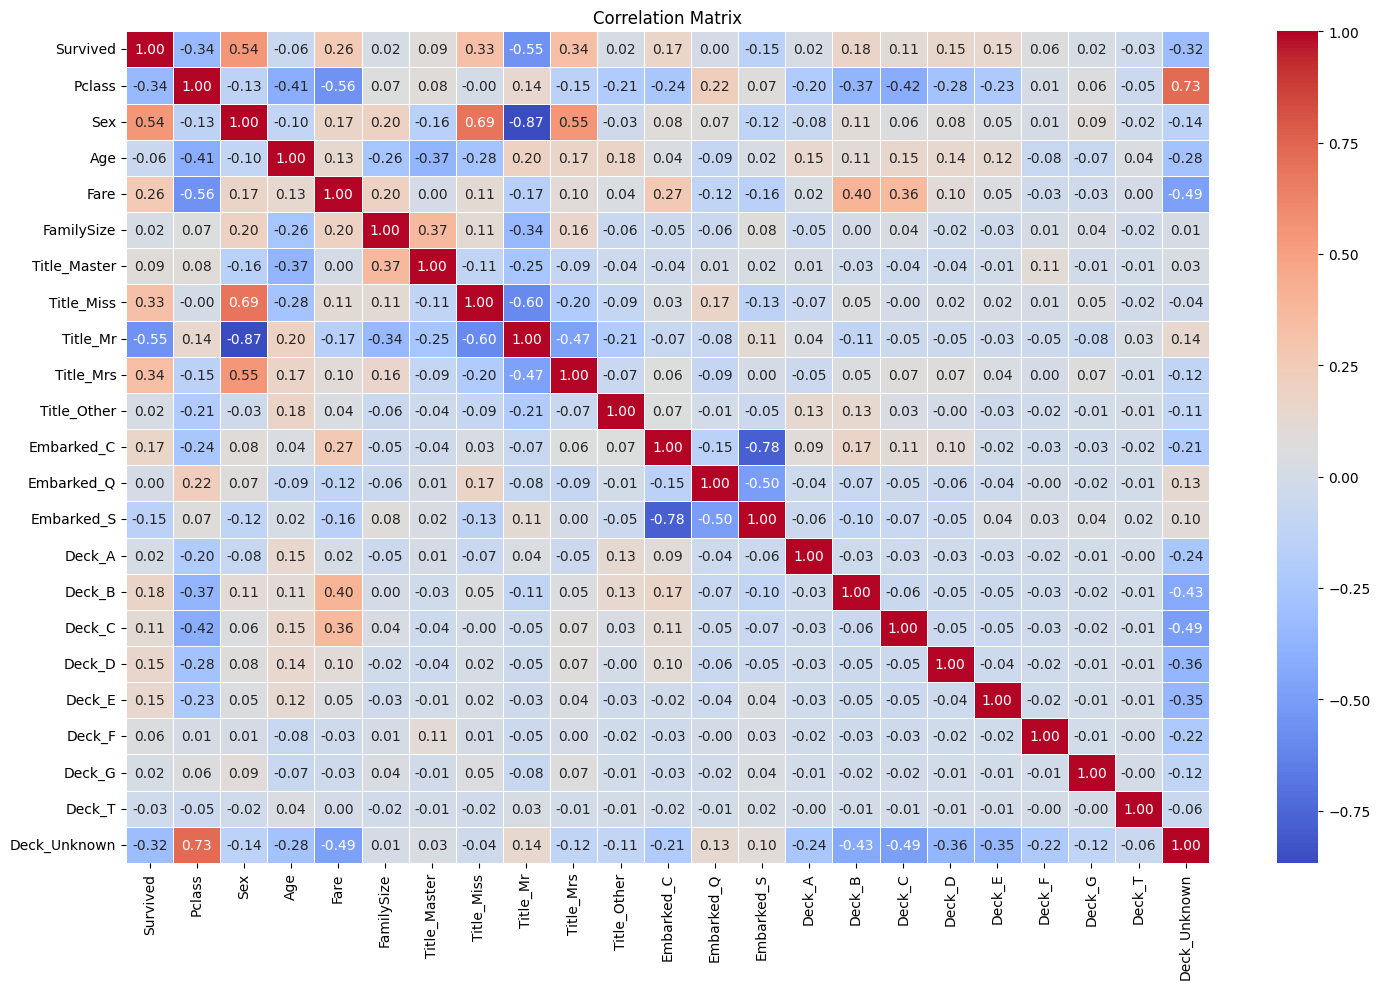

In [524]:
plot_correlation_matrix(titanic_df)

## Podsumowanie
Najsilniejsze predyktory: płeć (kobiety ~74%, mężczyżni ~19%)(korelacja 0,54), obecność numeru kabiny/pokładu, klasa (korelacja -0,34)(im większa klasa, tym większa szansa przeżycia). FamilySize ma nieliniowy związek - bardzo duże rodziny miały niższą przeżywalność. Age okazał się słabym predyktorem (korelacja -0,06). Przeżywalność rośnie do 72% dla rodzin 4-osobowych, po czym spada do 0-33% dla rodzin, które miały 5 osób i więcej.